*Ingeniería Estructural*

# FEM 1.001 — Booklet 3

> **Cálculo de los esfuerzos en las estructuras**

## Desarrollo teórico y aplicación estructural a grúas

**Autor:** *matias.hernandez@lind.cl* <br>
**Aplicación:** Evaluación estructural de grúas — Puerto Mejillones  
**Documento base:** FEM 1.001 — Rules for the Design of Hoisting Appliances

## 3.2.1 Verificación respecto al límite elástico

La sección **3.2.1 del FEM 1.001 Booklet 3** establece la verificación de los elementos estructurales respecto al límite elástico.

Esta sección aplica a los **miembros estructurales**, mientras que las uniones apernadas, remachadas y soldadas se verifican posteriormente en la sección 3.2.2.

El procedimiento implementado considera:

1. Determinación de la tensión normal admisible.
2. Determinación de la tensión de corte admisible.
3. Verificación de las tensiones normales individuales.
4. Verificación de la tensión de corte.
5. Cálculo de la tensión equivalente.
6. Determinación de los factores de utilización.
7. Obtención del factor de utilización gobernante.

---

## 1. Datos de entrada

Para un estado general de tensión plana se consideran:

- $\sigma_x$: tensión normal en la dirección local $x$.
- $\sigma_y$: tensión normal en la dirección local $y$.
- $\tau_{xy}$: tensión de corte en el plano $xy$.

Además, para determinar las tensiones admisibles se requiere:

- `material`: calidad del acero.
- `t`: espesor del elemento en mm.
- `case`: caso de carga FEM, correspondiente a `I`, `II` o `III`.
- `metodo`: procedimiento utilizado para determinar la tensión admisible.

En la implementación actual se utiliza preferentemente el **Booklet 9**, mediante la Tabla T.9.7.a, la cual entrega directamente:

$$
f_y,\qquad f_u,\qquad \sigma_a
$$

en función del material, el espesor y el caso FEM considerado.

Por ejemplo, para un acero S355 con:

$$
t=20\text{ mm}
$$

se utiliza el rango:

$$
t\leq40\text{ mm}
$$

obteniéndose:

$$
f_y=345\text{ MPa}
$$

$$
f_u=490\text{ MPa}
$$

y para **Case I**:

$$
\boxed{\sigma_a=230\text{ MPa}}
$$

---

## 2. Tensión normal admisible

La tensión normal calculada debe cumplir:

$$
|\sigma|\leq\sigma_a
$$

Para un estado bidimensional se verifican independientemente:

$$
|\sigma_x|\leq\sigma_a
$$

$$
|\sigma_y|\leq\sigma_a
$$

Los respectivos factores de utilización se definen como:

$$
FU_x=\frac{|\sigma_x|}{\sigma_a}
$$

$$
FU_y=\frac{|\sigma_y|}{\sigma_a}
$$

Un valor:

$$
FU\leq1.0
$$

indica cumplimiento de la condición evaluada.

---

## 3. Tensión de corte admisible

FEM establece que la tensión de corte admisible corresponde a:

$$
\boxed{
\tau_a=\frac{\sigma_a}{\sqrt{3}}
}
$$

Por lo tanto, debe cumplirse:

$$
|\tau_{xy}|\leq\tau_a
$$

El factor de utilización asociado al corte se define como:

$$
\boxed{
FU_\tau=\frac{|\tau_{xy}|}{\tau_a}
}
$$

---

## 4. Tensiones combinadas

Cuando en un mismo punto actúan simultáneamente:

$$
\sigma_x,\qquad\sigma_y,\qquad\tau_{xy}
$$

FEM exige calcular una tensión equivalente:

$$
\boxed{
\sigma_{eq}
=
\sqrt{
\sigma_x^2+
\sigma_y^2-
\sigma_x\sigma_y+
3\tau_{xy}^2
}
}
$$

La condición de aceptación corresponde a:

$$
\boxed{
\sigma_{eq}\leq\sigma_a
}
$$

El factor de utilización asociado a esta condición se define como:

$$
\boxed{
FU_{eq}=
\frac{\sigma_{eq}}{\sigma_a}
}
$$

Esta tensión equivalente permite representar en un único valor el efecto combinado de las tensiones normales y de corte presentes en el punto analizado.

---

## 5. Factores de utilización

La verificación completa considera los siguientes factores de utilización:

### Tensión normal en dirección $x$

$$
FU_x=
\frac{|\sigma_x|}{\sigma_a}
$$

### Tensión normal en dirección $y$

$$
FU_y=
\frac{|\sigma_y|}{\sigma_a}
$$

### Tensión de corte

$$
FU_\tau=
\frac{|\tau_{xy}|}{\tau_a}
$$

### Tensión equivalente

$$
FU_{eq}=
\frac{\sigma_{eq}}{\sigma_a}
$$

---

## 6. Factor de utilización gobernante

El factor de utilización final se define como el máximo de todas las verificaciones anteriores:

$$
\boxed{
FU=
\max
\left(
FU_x,\,
FU_y,\,
FU_\tau,\,
FU_{eq}
\right)
}
$$

La condición final de aceptación corresponde a:

$$
\boxed{
FU\leq1.0
\rightarrow
\text{OK}
}
$$

mientras que:

$$
\boxed{
FU>1.0
\rightarrow
\text{NO CUMPLE}
}
$$

El valor de $FU$ representa la fracción utilizada de la tensión admisible correspondiente a la condición que gobierna la verificación.

---

## 7. Ejemplo de aplicación

Se considera el siguiente estado tensional:

$$
\sigma_x=180\text{ MPa}
$$

$$
\sigma_y=60\text{ MPa}
$$

$$
\tau_{xy}=50\text{ MPa}
$$

para un acero:

$$
\text{S355}
$$

con espesor:

$$
t=20\text{ mm}
$$

y condición de carga:

$$
\text{Case I}
$$

De acuerdo con la Tabla T.9.7.a se obtiene:

$$
f_y=345\text{ MPa}
$$

$$
f_u=490\text{ MPa}
$$

$$
\sigma_a=230\text{ MPa}
$$

---

### Tensión de corte admisible

$$
\tau_a=
\frac{230}{\sqrt{3}}
$$

$$
\boxed{
\tau_a=132.79\text{ MPa}
}
$$

---

### Tensión equivalente

$$
\sigma_{eq}
=
\sqrt{
180^2+
60^2-
180(60)+
3(50)^2
}
$$

$$
\boxed{
\sigma_{eq}=180.83\text{ MPa}
}
$$

---

### Factor de utilización en $x$

$$
FU_x=
\frac{180}{230}
$$

$$
\boxed{
FU_x=0.783
}
$$

---

### Factor de utilización en $y$

$$
FU_y=
\frac{60}{230}
$$

$$
\boxed{
FU_y=0.261
}
$$

---

### Factor de utilización por corte

$$
FU_\tau=
\frac{50}{132.79}
$$

$$
\boxed{
FU_\tau=0.377
}
$$

---

### Factor de utilización por tensión equivalente

$$
FU_{eq}=
\frac{180.83}{230}
$$

$$
\boxed{
FU_{eq}=0.786
}
$$

---

### Factor de utilización gobernante

$$
FU=
\max
\left(
0.783,\,
0.261,\,
0.377,\,
0.786
\right)
$$

$$
\boxed{
FU=0.786
}
$$

Como:

$$
FU<1.0
$$

la verificación resulta:

$$
\boxed{
\text{Estado = OK}
}
$$

La condición gobernante corresponde en este caso a la **tensión equivalente combinada**.

---

## 8. Consideración para resultados de elementos Shell

Cuando la verificación se realice utilizando tensiones obtenidas desde elementos Shell en SAP2000, las componentes:

$$
\sigma_x,\qquad\sigma_y,\qquad\tau_{xy}
$$

deben corresponder al **mismo estado de resultados**.

Es decir, deben provenir simultáneamente del mismo:

- elemento;
- punto de integración o ubicación de resultados;
- Load Case o Load Combination;
- Step;
- cara superior o inferior, según corresponda.

No es recomendable combinar independientemente:

$$
\max|\sigma_x|
$$

$$
\max|\sigma_y|
$$

$$
\max|\tau_{xy}|
$$

si estos valores ocurren en estados diferentes.

El procedimiento recomendado consiste en calcular la tensión equivalente para cada conjunto simultáneo:

$$
(\sigma_x,\sigma_y,\tau_{xy})
$$

obteniendo:

$$
\sigma_{eq,i}
=
\sqrt{
\sigma_{x,i}^2+
\sigma_{y,i}^2-
\sigma_{x,i}\sigma_{y,i}+
3\tau_{xy,i}^2
}
$$

y posteriormente determinar el máximo factor de utilización:

$$
\boxed{
FU_{\max}
=
\max
\left(
\frac{\sigma_{eq,i}}{\sigma_a}
\right)
}
$$

entre todos los estados analizados.

---

## 9. Consideración sobre la sección resistente

Cuando las tensiones no provengan directamente de un modelo Shell y deban calcularse a partir de fuerzas internas, FEM distingue entre sección bruta y sección neta.

### Elementos en compresión

Se utiliza la sección bruta:

$$
A=A_g
$$

por lo tanto:

$$
\sigma=
\frac{N}{A_g}
$$

### Elementos en tracción

Se utiliza la sección neta, descontando las perforaciones correspondientes:

$$
A=A_n
$$

por lo tanto:

$$
\sigma=
\frac{N}{A_n}
$$

Esta consideración será particularmente importante al verificar elementos apernados o miembros donde existan perforaciones que reduzcan la sección resistente.

---

## 10. Resumen del procedimiento

El flujo general de la verificación corresponde a:

**Material + espesor + Case FEM**

$$
\Downarrow
$$

**Determinación de la tensión normal admisible**

$$
\sigma_a
$$

$$
\Downarrow
$$

**Determinación de la tensión de corte admisible**

$$
\tau_a=
\frac{\sigma_a}{\sqrt{3}}
$$

$$
\Downarrow
$$

**Estado tensional del punto**

$$
\sigma_x,\qquad
\sigma_y,\qquad
\tau_{xy}
$$

$$
\Downarrow
$$

**Tensión equivalente**

$$
\sigma_{eq}
=
\sqrt{
\sigma_x^2+
\sigma_y^2-
\sigma_x\sigma_y+
3\tau_{xy}^2
}
$$

$$
\Downarrow
$$

**Factores de utilización**

$$
FU_x,\qquad
FU_y,\qquad
FU_\tau,\qquad
FU_{eq}
$$

$$
\Downarrow
$$

**Factor de utilización gobernante**

$$
\boxed{
FU=
\max
\left(
FU_x,\,
FU_y,\,
FU_\tau,\,
FU_{eq}
\right)
}
$$

Finalmente:

$$
\boxed{
FU\leq1.0
\rightarrow
\text{OK}
}
$$

$$
\boxed{
FU>1.0
\rightarrow
\text{NO CUMPLE}
}
$$

In [4]:
import numpy as np

# =============================================================================
# FEM 1.001 - BOOKLET 3
# 3.2.1 - CHECKING WITH RESPECT TO THE ELASTIC LIMIT
# =============================================================================

# Coeficientes de seguridad respecto al límite elástico - Booklet 3
NU_E={"I":1.50,"II":1.33,"III":1.10}

# Tensiones admisibles del acero A.52 de referencia [MPa] - Booklet 3
SIGMA_A52={"I":240.0,"II":270.0,"III":325.0}

# Tabla T.9.7.a - Booklet 9
# (t_max [mm], fy [MPa], fu [MPa], sigma_a_I, sigma_a_II, sigma_a_III)
T9_7A={
    "S235":[
        (16,235,340,157,177,214),
        (40,225,340,150,169,205),
        (100,215,340,143,162,195),
        (150,195,340,130,147,177),
        (200,185,320,123,139,168),
        (250,175,320,117,132,159)
    ],
    "S275":[
        (16,275,410,183,207,250),
        (40,265,410,177,199,241),
        (63,255,410,170,192,232),
        (80,245,410,163,184,223),
        (100,235,410,157,177,214),
        (150,225,400,150,169,205),
        (200,215,380,143,162,195),
        (250,205,380,137,154,186)
    ],
    "S355":[
        (16,355,490,237,267,323),
        (40,345,490,230,259,314),
        (63,335,490,223,252,305),
        (80,325,490,217,244,295),
        (100,315,490,210,237,286),
        (150,295,470,197,222,268),
        (200,285,450,190,214,259),
        (250,275,450,183,207,250)
    ],
    "S460_EN10113":[
        (16,460,550,307,346,418),
        (40,440,550,293,331,400),
        (63,430,550,287,323,391),
        (80,410,550,273,308,373),
        (100,400,550,267,301,364)
    ],
    "S460_EN10137":[
        (50,460,550,307,346,418),
        (100,440,550,293,331,400),
        (150,400,500,267,301,364)
    ],
    "S690_EN10137":[
        (50,690,770,460,519,627),
        (100,650,760,433,489,591),
        (150,630,710,420,474,573)
    ],
    "S890_EN10137":[
        (50,890,940,593,669,809),
        (100,830,880,553,624,755)
    ],
    "S960_EN10137":[
        (50,960,980,640,722,873)
    ]
}

ALIASES={"FE360":"S235","FE440":"S275","FE510":"S355"}

def _case_fem(case):
    case=str(case).upper().replace("CASE","").strip()
    if case not in NU_E: raise ValueError("case debe ser 'I', 'II' o 'III'")
    return case

def material_t9_7a(material,t):
    material=ALIASES.get(str(material).upper(),str(material).upper())
    keys={k.upper():k for k in T9_7A}
    if material not in keys: raise ValueError(f"Material '{material}' no incorporado en T9_7A")
    key=keys[material]
    if t<=0: raise ValueError("El espesor debe ser > 0 mm")

    for tmax,fy,fu,sI,sII,sIII in T9_7A[key]:
        if t<=tmax:
            return {
                "material":key,
                "t":float(t),
                "t_max":float(tmax),
                "fy":float(fy),
                "fu":float(fu),
                "fy_fu":float(fy/fu),
                "sigma_a_I":float(sI),
                "sigma_a_II":float(sII),
                "sigma_a_III":float(sIII)
            }

    raise ValueError(f"Espesor t={t} mm fuera del rango incorporado para {key}")

def sigma_adm_booklet3(fy,fu,case):
    case=_case_fem(case)
    fy=float(fy)
    fu=float(fu)

    if fy<=0 or fu<=0: raise ValueError("fy y fu deben ser > 0")
    if fy>fu: raise ValueError("Debe cumplirse fy <= fu")

    ratio=fy/fu

    sigma_low=fy/NU_E[case]
    sigma_high=((fy+fu)/(360.0+510.0))*SIGMA_A52[case]

    if ratio<0.70:
        sigma_a=sigma_low
        criterio="fy/fu < 0.70 → sigma_a = fy/nu_E"

    elif ratio>0.70:
        sigma_a=sigma_high
        criterio="fy/fu > 0.70 → acero de alto límite elástico"

    else:
        sigma_a=min(sigma_low,sigma_high)
        criterio="fy/fu = 0.70 → mínimo de ambas expresiones (criterio conservador adoptado)"

    return {
        "fy":fy,
        "fu":fu,
        "fy_fu":float(ratio),
        "case":case,
        "nu_E":float(NU_E[case]),
        "sigma_a":float(sigma_a),
        "criterio":criterio,
        "metodo":"Booklet 3 original"
    }

def sigma_adm_fem(case,material=None,t=None,fy=None,fu=None,metodo="booklet9"):
    case=_case_fem(case)
    metodo=str(metodo).lower()

    if metodo=="booklet9":
        if material is None or t is None: raise ValueError("Para Booklet 9 debes indicar material y espesor t")
        mat=material_t9_7a(material,t)
        sigma_a=mat[f"sigma_a_{case}"]

        return {
            "material":mat["material"],
            "t":mat["t"],
            "fy":mat["fy"],
            "fu":mat["fu"],
            "fy_fu":mat["fy_fu"],
            "case":case,
            "sigma_a":float(sigma_a),
            "criterio":"Tabla T.9.7.a",
            "metodo":"Booklet 9"
        }

    elif metodo=="booklet3":
        if fy is None or fu is None: raise ValueError("Para Booklet 3 debes indicar fy y fu")
        return sigma_adm_booklet3(fy,fu,case)

    else:
        raise ValueError("metodo debe ser 'booklet9' o 'booklet3'")

def tau_adm_fem(sigma_a):
    return float(sigma_a/np.sqrt(3))

def sigma_eq_fem(sigma_x,sigma_y=0,tau_xy=0):
    return float(np.sqrt(sigma_x**2+sigma_y**2-sigma_x*sigma_y+3*tau_xy**2))

def elastic_limit_fem(sigma_x,sigma_y=0,tau_xy=0,case="I",material=None,t=None,fy=None,fu=None,metodo="booklet9"):
    adm=sigma_adm_fem(case,material,t,fy,fu,metodo)

    sigma_a=adm["sigma_a"]
    tau_a=tau_adm_fem(sigma_a)
    sigma_eq=sigma_eq_fem(sigma_x,sigma_y,tau_xy)

    FU_x=abs(sigma_x)/sigma_a
    FU_y=abs(sigma_y)/sigma_a
    FU_tau=abs(tau_xy)/tau_a
    FU_eq=sigma_eq/sigma_a
    FU=max(FU_x,FU_y,FU_tau,FU_eq)

    return {
        **adm,
        "tau_a":round(tau_a,3),
        "sigma_x":float(sigma_x),
        "sigma_y":float(sigma_y),
        "tau_xy":float(tau_xy),
        "sigma_eq":round(sigma_eq,3),
        "FU_x":round(FU_x,3),
        "FU_y":round(FU_y,3),
        "FU_tau":round(FU_tau,3),
        "FU_eq":round(FU_eq,3),
        "FU":round(FU,3),
        "Estado":"OK" if FU<=1 else "NO CUMPLE"
    }

In [5]:
resultado=elastic_limit_fem(
    sigma_x=180,
    sigma_y=60,
    tau_xy=50,
    material="S355",
    t=20,
    case="I",
    metodo="booklet9"
)

resultado

{'material': 'S355',
 't': 20.0,
 'fy': 345.0,
 'fu': 490.0,
 'fy_fu': 0.7040816326530612,
 'case': 'I',
 'sigma_a': 230.0,
 'criterio': 'Tabla T.9.7.a',
 'metodo': 'Booklet 9',
 'tau_a': 132.791,
 'sigma_x': 180.0,
 'sigma_y': 60.0,
 'tau_xy': 50.0,
 'sigma_eq': 180.831,
 'FU_x': 0.783,
 'FU_y': 0.261,
 'FU_tau': 0.377,
 'FU_eq': 0.786,
 'FU': 0.786,
 'Estado': 'OK'}

# Verificación estructural según FEM 1.001

El procedimiento de evaluación se divide en dos verificaciones independientes:

1. **Verificación elástica:** comprueba que las tensiones desarrolladas bajo los casos de carga FEM no superen las tensiones admisibles del material.
2. **Verificación por fatiga:** comprueba que la fluctuación repetitiva de las tensiones durante la operación pueda ser resistida durante la vida útil considerada del componente.

Ambas verificaciones utilizan las tensiones locales obtenidas del modelo numérico, pero emplean criterios de capacidad diferentes.

---

# 1. Verificación elástica

## 1.1 Datos del material

Para cada acero se requieren:

- $f_y$: límite elástico o tensión de fluencia.
- $f_u$: resistencia última a tracción.

Se calcula inicialmente:

$$
r=\frac{f_y}{f_u}
$$

Este cociente determina el procedimiento utilizado para obtener la tensión admisible.

---

## 1.2 Tensión normal admisible

### Caso $f_y/f_u<0.70$

La tensión admisible se determina como:

$$
\sigma_a=\frac{f_y}{\nu_E}
$$

donde:

$$
\nu_E=
\begin{cases}
1.50 & \text{Case I}\\
1.33 & \text{Case II}\\
1.10 & \text{Case III}
\end{cases}
$$

Por lo tanto, la capacidad depende del caso de carga FEM que se esté verificando.

---

### Caso $f_y/f_u>0.70$

Para aceros con alta relación entre límite elástico y resistencia última se utiliza:

$$
\sigma_a=
\frac{f_y+f_u}{360+510}\,
\sigma_{a,52}
$$

donde:

$$
\sigma_{a,52}=
\begin{cases}
240\text{ MPa} & \text{Case I}\\
270\text{ MPa} & \text{Case II}\\
325\text{ MPa} & \text{Case III}
\end{cases}
$$

El valor exacto $f_y/f_u=0.70$ no está definido explícitamente por FEM 1.001. Para la implementación puede adoptarse un criterio conservador utilizando el menor admisible obtenido mediante ambas expresiones.

---

## 1.3 Tensión admisible a corte

Una vez obtenida $\sigma_a$, la tensión admisible a corte del material es:

$$
\tau_a=\frac{\sigma_a}{\sqrt{3}}
$$

---

## 1.4 Casos de carga FEM

La verificación elástica debe realizarse para los Cases I, II y III que correspondan.

Las combinaciones deben ser construidas previamente en el modelo numérico.

Para una grúa clasificada A8:

$$
\gamma_C=1.20
$$

De forma general:

### Case I

$$
\gamma_C(S_G+\psi S_L+S_H)
$$

### Case II

$$
\gamma_C(S_G+\psi S_L+S_H)+S_W
$$

### Case III

Considera las combinaciones excepcionales definidas por FEM, por ejemplo la condición fuera de servicio:

$$
S_G+S_{W,\max}
$$

Los factores de combinación deben estar incorporados en las combinaciones del modelo numérico.  
La rutina de verificación no debe volver a amplificar las tensiones obtenidas desde SAP2000.

---

## 1.5 Demanda local en elementos shell

Para cada elemento shell se extraen las tensiones locales:

$$
S11
$$

$$
S22
$$

$$
S12
$$

Estas tensiones deben corresponder simultáneamente a:

- el mismo elemento;
- el mismo punto de evaluación;
- la misma cara del shell;
- el mismo caso o combinación de carga.

Para placas sometidas a flexión deben verificarse independientemente las caras **Top** y **Bottom**.

Se identifica:

$$
\sigma_x=S11
$$

$$
\sigma_y=S22
$$

$$
\tau_{xy}=S12
$$

---

## 1.6 Tensión equivalente

La tensión equivalente para un estado plano de tensiones se calcula como:

$$
\sigma_{cp}
=
\sqrt{
\sigma_x^2+
\sigma_y^2-
\sigma_x\sigma_y+
3\tau_{xy}^2
}
$$

Esta expresión corresponde a la tensión equivalente utilizada por FEM para cargas combinadas.

---

## 1.7 Condiciones de verificación elástica

Deben comprobarse individualmente:

$$
|\sigma_x|\le\sigma_a
$$

$$
|\sigma_y|\le\sigma_a
$$

$$
|\tau_{xy}|\le\tau_a
$$

y adicionalmente:

$$
\sigma_{cp}\le\sigma_a
$$

Pueden definirse factores de utilización:

$$
FU_x=\frac{|\sigma_x|}{\sigma_a}
$$

$$
FU_y=\frac{|\sigma_y|}{\sigma_a}
$$

$$
FU_{\tau}=\frac{|\tau_{xy}|}{\tau_a}
$$

$$
FU_{VM}=\frac{\sigma_{cp}}{\sigma_a}
$$

La condición general es:

$$
FU\le1.0
$$

Cuando se disponga de los estados simultáneos de tensión, se deben conservar las componentes correspondientes al mismo estado de carga. Utilizar máximos independientes de $\sigma_x$, $\sigma_y$ y $\tau_{xy}$ es conservador, pero puede generar una combinación que no ocurra físicamente.

---

# 2. Verificación por fatiga

La verificación por fatiga es independiente de la verificación elástica.

La capacidad de fatiga no se obtiene simplemente dividiendo $f_y$ por un factor de seguridad, sino que depende de:

- número de ciclos de tensión;
- espectro de tensiones;
- clasificación del componente;
- tipo de detalle estructural;
- efecto de entalla;
- relación entre los extremos de tensión.

El procedimiento general es:

$$
n\rightarrow B
$$

$$
k_{sp}\rightarrow P
$$

$$
B+P\rightarrow E
$$

$$
E+W/K\rightarrow\sigma_W
$$

$$
\sigma_{\max},\sigma_{\min}\rightarrow\kappa
$$

$$
\sigma_W+\kappa\rightarrow\sigma_{adm,\;fatiga}
$$

---

# 3. Demanda utilizada para fatiga

La fatiga estructural según FEM se evalúa utilizando solamente los estados correspondientes a **Case I**.

Para fatiga no se aplica el coeficiente amplificador $\gamma_C$.

Por lo tanto, para una grúa A8 no se utiliza el factor $1.20$ en la historia de tensiones utilizada para fatiga.

La historia operacional debe representar las tensiones producidas por:

$$
S_G+\psi S_L+S_H
$$

durante las distintas posiciones y etapas posibles de operación de la grúa.

Los Cases II y III continúan siendo necesarios para las verificaciones resistentes, pero no forman parte de la determinación de $\sigma_{\max}$, $\sigma_{\min}$ y $\kappa$ utilizada por FEM para fatiga.

---

# 4. Evaluación local de la fatiga

La fatiga se evalúa localmente.

Para un determinado shell, cara y punto físico deben conservarse las tensiones correspondientes a cada estado operacional:

$$
S11(t)
$$

$$
S22(t)
$$

$$
S12(t)
$$

Cada ubicación de la estructura puede tener una historia de tensiones diferente.

Por lo tanto, una placa no posee necesariamente una única demanda de fatiga global. La evaluación debe realizarse en las zonas potencialmente críticas y posteriormente determinar la mayor utilización.

Las zonas pueden clasificarse de acuerdo con el detalle físico presente, por ejemplo:

- material continuo;
- zonas perforadas;
- proximidad de soldaduras;
- rigidizadores;
- cambios geométricos;
- otras discontinuidades.

---

# 5. Número de ciclos y clase de utilización B

La duración de uso del componente se expresa mediante el número de ciclos locales de tensión:

$$
n
$$

Un ciclo de operación completo de la grúa no necesariamente corresponde a un único ciclo de tensión en cada componente.

Un mismo componente puede experimentar varios ciclos locales durante un ciclo de la grúa.

FEM clasifica el número de ciclos en:

| Clase | Número de ciclos |
|---|---:|
| B0 | $n\le16\,000$ |
| B1 | $16\,000<n\le32\,000$ |
| B2 | $32\,000<n\le63\,000$ |
| B3 | $63\,000<n\le125\,000$ |
| B4 | $125\,000<n\le250\,000$ |
| B5 | $250\,000<n\le500\,000$ |
| B6 | $500\,000<n\le1\,000\,000$ |
| B7 | $1\,000\,000<n\le2\,000\,000$ |
| B8 | $2\,000\,000<n\le4\,000\,000$ |
| B9 | $4\,000\,000<n\le8\,000\,000$ |
| B10 | $n>8\,000\,000$ |

---

# 6. Espectro de tensiones y clase P

La cantidad de ciclos no describe por sí sola la severidad de la fatiga.

FEM introduce el factor de espectro:

$$
k_{sp}
$$

que representa la distribución de las magnitudes de tensión durante la vida del componente.

Para un espectro discretizado:

$$
k_{sp}
=
\sum_i
\left(
\frac{\sigma_i}{\sigma_{\max}}
\right)^c
\frac{n_i}{n}
$$

donde $c$ depende de las características del componente, material, geometría, acabado superficial y otras condiciones definidas por FEM.

Para componentes estructurales, la determinación del espectro considera las diferencias:

$$
\sigma_{sup}-\sigma_m
$$

y no simplemente el valor absoluto de la tensión en cada estado.

Las clases de espectro son:

| Clase | $k_{sp}$ |
|---|---:|
| P1 | $k_{sp}\le0.125$ |
| P2 | $0.125<k_{sp}\le0.250$ |
| P3 | $0.250<k_{sp}\le0.500$ |
| P4 | $0.500<k_{sp}\le1.000$ |

---

# 7. Grupo del componente E

La clase de utilización $B$ y la clase de espectro $P$ se combinan mediante la Tabla T.2.1.4.4 de FEM para obtener:

$$
E1,\;E2,\ldots,E8
$$

El grupo $E$ representa conjuntamente:

- cantidad de ciclos;
- severidad del espectro de tensiones.

A mayor grupo $E$, menor es generalmente la resistencia admisible a fatiga.

El grupo $E$ se utiliza posteriormente como fila de entrada en la tabla de resistencia base $\sigma_W$.

---

# 8. Clasificación del detalle W/K

La resistencia a fatiga depende también de la geometría local del detalle.

FEM incorpora el efecto de concentración de tensiones o **notch effect** mediante categorías de construcción.

## Elementos no soldados

$$
W0,\;W1,\;W2
$$

- $W0$: material continuo sin efecto significativo de entalla.
- $W1$ y $W2$: elementos perforados y detalles con mayor efecto de discontinuidad.

## Elementos soldados

$$
K0,\;K1,\;K2,\;K3,\;K4
$$

La severidad del detalle aumenta desde $K0$ hacia $K4$.

Una misma unión puede tener categorías diferentes dependiendo de la dirección de la tensión respecto del detalle.

Por lo tanto, en un shell puede ser necesario definir independientemente:

$$
detalle_{11}
$$

y:

$$
detalle_{22}
$$

La categoría $W/K$ no debe ser asignada automáticamente por el código. Debe definirse a partir de la geometría física real y de las tablas de clasificación de FEM.

---

# 9. Resistencia base de fatiga $\sigma_W$

Una vez conocidos:

$$
E
$$

y:

$$
W/K
$$

se obtiene de la Tabla T.A.3.6.1:

$$
\sigma_W
$$

El valor $\sigma_W$ corresponde a la resistencia base para una tensión completamente alternante:

$$
+\sigma_W\leftrightarrow-\sigma_W
$$

por lo tanto:

$$
\kappa=-1
$$

Para elementos no soldados $W0$-$W2$, FEM diferencia entre las familias de acero consideradas en la tabla.

Para detalles soldados $K0$-$K4$, FEM utiliza los mismos valores de $\sigma_W$ para los aceros St37, St44 y St52 contemplados por la norma.

---

# 10. Determinación de los extremos de tensión

Para cada componente de tensión se analiza su historia completa de Case I:

$$
S11(t)
$$

$$
S22(t)
$$

$$
S12(t)
$$

FEM define $\sigma_{\max}$ como el extremo con mayor valor absoluto, conservando su signo.

Para cada componente se determinan:

$$
\sigma_{\max}
$$

$$
\sigma_{\min}
$$

y:

$$
\kappa=
\frac{\sigma_{\min}}{\sigma_{\max}}
$$

Para corte:

$$
\kappa_{\tau}
=
\frac{\tau_{\min}}{\tau_{\max}}
$$

Por lo tanto se calculan independientemente:

$$
\kappa_{11}
$$

$$
\kappa_{22}
$$

$$
\kappa_{12}
$$

Los signos deben conservarse durante todo el procedimiento.

---

# 11. Capacidad normal a fatiga

Una vez conocido $\sigma_W$ y $\kappa$, FEM obtiene el esfuerzo admisible.

## Para $\kappa\le0$

En tracción:

$$
\sigma_t=
\frac{5\sigma_W}
{3-2\kappa}
$$

En compresión:

$$
\sigma_c=
\frac{2\sigma_W}
{1-\kappa}
$$

---

## Para $\kappa>0$

Primero:

$$
\sigma_0=
\frac{5}{3}\sigma_W
$$

y:

$$
\sigma_{+1}=0.75f_u
$$

Luego:

$$
\sigma_t=
\frac{\sigma_0}
{
1-\kappa
\left(
1-\frac{\sigma_0}{\sigma_{+1}}
\right)
}
$$

y:

$$
\sigma_c=1.2\sigma_t
$$

La tensión admisible de tracción queda limitada a:

$$
\sigma_t\le0.75f_u
$$

El esfuerzo predominante se determina mediante el signo de $\sigma_{\max}$:

- $\sigma_{\max}>0$: tracción predominante.
- $\sigma_{\max}<0$: compresión predominante.

---

# 12. Capacidad a corte por fatiga

## Corte en el material estructural

Para el material de una placa:

$$
\tau_{adm}
=
\frac{\sigma_{t,W0}}{\sqrt{3}}
$$

donde $\sigma_{t,W0}$ debe determinarse utilizando:

- el mismo grupo $E$;
- detalle $W0$;
- el valor de $\kappa_{12}$ correspondiente a la historia de corte.

---

## Corte en una soldadura

Para el cordón de soldadura:

$$
\tau_{adm,weld}
=
\frac{\sigma_{t,K0}}{\sqrt{2}}
$$

---

# 13. Verificaciones individuales de fatiga

Para cada dirección deben comprobarse:

$$
|S11_{\max}|
\le
\sigma_{11,adm}
$$

$$
|S22_{\max}|
\le
\sigma_{22,adm}
$$

$$
|S12_{\max}|
\le
\tau_{12,adm}
$$

Pueden definirse:

$$
FU_{11}
=
\frac{|S11_{\max}|}
{\sigma_{11,adm}}
$$

$$
FU_{22}
=
\frac{|S22_{\max}|}
{\sigma_{22,adm}}
$$

$$
FU_{12}
=
\frac{|S12_{\max}|}
{\tau_{12,adm}}
$$

La condición individual es:

$$
FU\le1.0
$$

---

# 14. Interacción de fatiga

Cuando las componentes normales y de corte son relevantes simultáneamente, FEM utiliza:

$$
R=
\left(
\frac{\sigma_x}{\sigma_{xa}}
\right)^2
+
\left(
\frac{\sigma_y}{\sigma_{ya}}
\right)^2
-
\frac{
\sigma_x\sigma_y
}{
|\sigma_{xa}||\sigma_{ya}|
}
+
\left(
\frac{\tau_{xy}}{\tau_{xya}}
\right)^2
$$

La condición general es:

$$
R\le1
$$

Los signos de $\sigma_x$ y $\sigma_y$ deben conservarse debido al término de interacción:

$$
-\frac{\sigma_x\sigma_y}
{|\sigma_{xa}||\sigma_{ya}|}
$$

FEM indica además que, debido al carácter severo de la interacción, valores ligeramente superiores a $1$ pueden aceptarse si:

$$
\sqrt{R}\le1.05
$$

Para la evaluación habitual se adopta:

$$
R\le1
$$

---

# 15. Estados simultáneos de tensión

Existen dos alternativas para la interacción:

### Método conservador

Combinar independientemente:

$$
\sigma_{x,\max}
$$

$$
\sigma_{y,\max}
$$

$$
\tau_{xy,\max}
$$

aunque no ocurran simultáneamente.

Este procedimiento es conservador.

### Método basado en estados reales

Mantener para cada estado operacional el conjunto simultáneo:

$$
[\sigma_x,\sigma_y,\tau_{xy}]_i
$$

y evaluar las combinaciones físicamente posibles.

Para modelos numéricos donde se dispone de los resultados de cada estado operacional, es preferible conservar esta correspondencia entre componentes.

---

# 16. Aplicación a elementos shell

Para cada shell crítico se debe conservar:

- identificación del elemento;
- zona de detalle;
- cara Top o Bottom;
- $S11$;
- $S22$;
- $S12$;
- estado operacional correspondiente.

El procedimiento debe ejecutarse independientemente para ambas caras del shell.

La evaluación por fatiga es local. Por lo tanto, diferentes zonas de una misma placa pueden poseer:

- diferentes historias de tensión;
- diferentes valores de $\kappa$;
- diferentes categorías $W/K$;
- diferentes capacidades admisibles.

La placa puede dividirse en zonas de detalle y buscar posteriormente el mayor factor de utilización dentro de cada zona.

---

# 17. Flujo general de cálculo

## Verificación elástica

$$
f_y,f_u
\rightarrow
\sigma_a(Case\ I,\ II,\ III)
$$

$$
SAP2000
\rightarrow
S11,S22,S12
$$

$$
S11,S22,S12
\rightarrow
\sigma_{cp}
$$

$$
\text{Demanda}
\le
\text{Capacidad elástica}
$$

---

## Verificación por fatiga

$$
\text{Historia operacional Case I sin }\gamma_C
$$

$$
\downarrow
$$

$$
S11(t),S22(t),S12(t)
$$

$$
\downarrow
$$

$$
n\rightarrow B
$$

$$
k_{sp}\rightarrow P
$$

$$
B+P\rightarrow E
$$

$$
E+W/K\rightarrow\sigma_W
$$

$$
\sigma_{\max},\sigma_{\min}
\rightarrow
\kappa
$$

$$
\sigma_W+\kappa+f_u
\rightarrow
\sigma_{adm,\;fatiga}
$$

$$
\downarrow
$$

$$
\text{Verificaciones individuales}
+
\text{interacción}
$$

$$
\downarrow
$$

$$
FU\le1.0
$$

In [6]:
from math import sqrt

# --------------------------------------------------------------------------------------------------
# CAPACIDAD ELÁSTICA - FEM 1.001 BOOKLET 3 (3.2.1.1)
# --------------------------------------------------------------------------------------------------

def sigma_adm_elastica(fy, fu, case):
    
    nu_E = {'I':1.50, 'II':1.33, 'III':1.10}
    sigma_A52 = {'I':240.0, 'II':270.0, 'III':325.0}

    case = case.upper()
    
    if case not in nu_E:
        raise ValueError("case debe ser 'I', 'II' o 'III'")
    
    r = fy/fu

    # fy/fu < 0.70
    if r < 0.70:
        sigma_a = fy/nu_E[case]
        metodo = 'fy / nu_E'

    # fy/fu > 0.70
    elif r > 0.70:
        sigma_a = ((fy + fu)/(360.0 + 510.0))*sigma_A52[case]
        metodo = 'acero de alto límite elástico'

    # FEM no especifica explícitamente el caso exacto fy/fu = 0.70
    else:
        sigma_1 = fy/nu_E[case]
        sigma_2 = ((fy + fu)/(360.0 + 510.0))*sigma_A52[case]
        sigma_a = min(sigma_1, sigma_2)  # criterio conservador
        metodo = 'fy/fu = 0.70 -> mínimo conservador'

    return {
        'fy_fu': r,
        'case': case,
        'sigma_a': sigma_a,
        'tau_a': sigma_a/sqrt(3),
        'metodo': metodo
    }

In [7]:
calidad_acero = {"AE355D":{"Fy":355, "Fu":510},
                 "AE275D":{"Fy":275, "Fu":410},
                 "A42-27ES":{"Fy":270, "Fu":420},
                 "A36":{"Fy":250, "Fu":400}}

In [8]:
cap = sigma_adm_elastica(fy = calidad_acero["AE355D"]["Fy"], fu = calidad_acero["AE355D"]["Fu"], case = 'I') 
cap

{'fy_fu': 0.696078431372549,
 'case': 'I',
 'sigma_a': 236.66666666666666,
 'tau_a': 136.63956370821143,
 'metodo': 'fy / nu_E'}

In [9]:
# --------------------------------------------------------------------------------------------------
# DEMANDA ELÁSTICA - SHELL
# --------------------------------------------------------------------------------------------------

def demanda_shell(S11, S22, S12):
    SVM = sqrt(S11**2 + S22**2 - S11*S22 + 3*S12**2)
    return {
        'S11': S11,
        'S22': S22,
        'S12': S12,
        'SVM': SVM
    }

In [30]:
demanda_shell(-80.1, -1854.15, 372.1)

{'S11': -80.1, 'S22': -1854.15, 'S12': 372.1, 'SVM': 1926.433504562252}

In [31]:
demanda_shell(-780.96, -2085.1, 316.03)

{'S11': -780.96, 'S22': -2085.1, 'S12': 316.03, 'SVM': 1904.9371953689183}

In [32]:
# --------------------------------------------------------------------------------------------------
# VERIFICACIÓN ELÁSTICA
# --------------------------------------------------------------------------------------------------

def check_elastico(fy, fu, case, S11, S22, S12):

    cap = sigma_adm_elastica(fy, fu, case)
    dem = demanda_shell(S11, S22, S12)

    sigma_a = cap['sigma_a']
    tau_a = cap['tau_a']

    FU_11 = abs(S11)/sigma_a
    FU_22 = abs(S22)/sigma_a
    FU_12 = abs(S12)/tau_a
    FU_VM = dem['SVM']/sigma_a

    return {
        'case': case,
        'sigma_a': sigma_a,
        'tau_a': tau_a,
        'S11': S11,
        'S22': S22,
        'S12': S12,
        'SVM': dem['SVM'],
        'FU_11': FU_11,
        'FU_22': FU_22,
        'FU_12': FU_12,
        'FU_VM': FU_VM,
        'FU_max': max(FU_11, FU_22, FU_12, FU_VM),
        'OK': max(FU_11, FU_22, FU_12, FU_VM) <= 1.0
    }

In [39]:
resultado = check_elastico(
    fy = calidad_acero["A36"]["Fy"],
    fu = calidad_acero["A36"]["Fu"],
    case = 'I',
    S11 = -80.1/10,
    S22 = -1854.15/10,
    S12 = 372.1/10
)

resultado

{'case': 'I',
 'sigma_a': 166.66666666666666,
 'tau_a': 96.22504486493763,
 'S11': -8.01,
 'S22': -185.41500000000002,
 'S12': 37.21,
 'SVM': 192.64335045622522,
 'FU_11': 0.04806,
 'FU_22': 1.1124900000000002,
 'FU_12': 0.38669766329782757,
 'FU_VM': 1.1558601027373514,
 'FU_max': 1.1558601027373514,
 'OK': False}

In [40]:
resultado = check_elastico(
    fy = calidad_acero["A36"]["Fy"],
    fu = calidad_acero["A36"]["Fu"],
    case = 'II',
    S11 = -780.96/10,
    S22 = -2085.1/10,
    S12 = 316.03/10
)

resultado

{'case': 'II',
 'sigma_a': 187.96992481203006,
 'tau_a': 108.52448668977928,
 'S11': -78.096,
 'S22': -208.51,
 'S12': 31.602999999999998,
 'SVM': 190.49371953689183,
 'FU_11': 0.41547072000000007,
 'FU_22': 1.1092732,
 'FU_12': 0.2912061688929079,
 'FU_VM': 1.0134265879362647,
 'FU_max': 1.1092732,
 'OK': False}

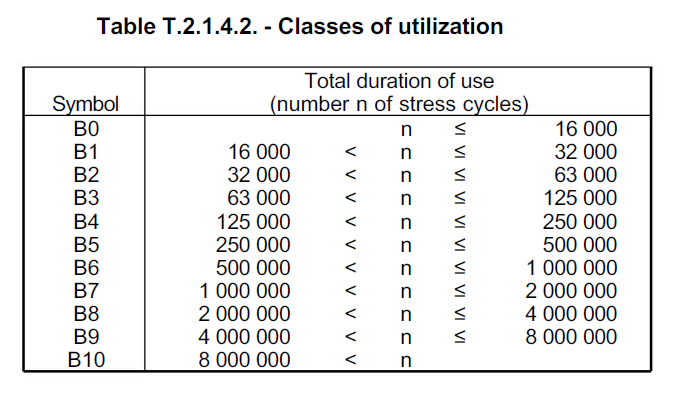

In [35]:
# --------------------------------------------------------------------------------------------------
# CLASE DE UTILIZACIÓN B
# --------------------------------------------------------------------------------------------------

def clase_B(n):

    limites = [
        (16000,   'B0'),
        (32000,   'B1'),
        (63000,   'B2'),
        (125000,  'B3'),
        (250000,  'B4'),
        (500000,  'B5'),
        (1000000, 'B6'), 
        (2000000, 'B7'),
        (4000000, 'B8'),
        (8000000, 'B9')
    ]

    for limite, B in limites:
        if n <= limite:
            return B

    return 'B10'

In [36]:
clase_B(5_000_000)

'B9'

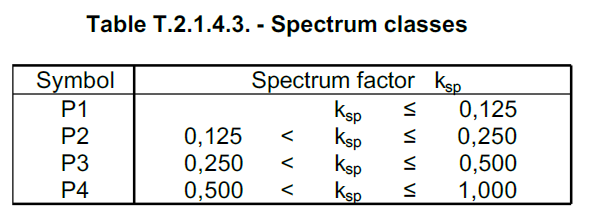

In [37]:
# --------------------------------------------------------------------------------------------------
# CLASE DE ESPECTRO P
# --------------------------------------------------------------------------------------------------

def clase_P(ksp):

    if ksp <= 0.125:
        return 'P1'

    elif ksp <= 0.250:
        return 'P2'

    elif ksp <= 0.500:
        return 'P3'

    elif ksp <= 1.000:
        return 'P4'

    else:
        raise ValueError("ksp debe estar entre 0 y 1")

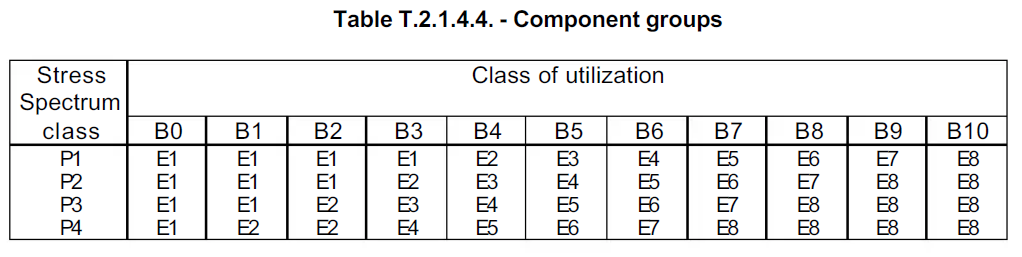

In [38]:
# --------------------------------------------------------------------------------------------------
# GRUPO DEL COMPONENTE E
# --------------------------------------------------------------------------------------------------

TABLA_E = {

    'P1': {
        'B0':'E1', 'B1':'E1', 'B2':'E1', 'B3':'E1',
        'B4':'E2', 'B5':'E3', 'B6':'E4', 'B7':'E5',
        'B8':'E6', 'B9':'E7', 'B10':'E8'
    },

    'P2': {
        'B0':'E1', 'B1':'E1', 'B2':'E1', 'B3':'E2',
        'B4':'E3', 'B5':'E4', 'B6':'E5', 'B7':'E6',
        'B8':'E7', 'B9':'E8', 'B10':'E8'
    },

    'P3': {
        'B0':'E1', 'B1':'E1', 'B2':'E2', 'B3':'E3',
        'B4':'E4', 'B5':'E5', 'B6':'E6', 'B7':'E7',
        'B8':'E8', 'B9':'E8', 'B10':'E8'
    },

    'P4': {
        'B0':'E1', 'B1':'E2', 'B2':'E3', 'B3':'E4',
        'B4':'E5', 'B5':'E6', 'B6':'E7', 'B7':'E8',
        'B8':'E8', 'B9':'E8', 'B10':'E8'
    }
}


def grupo_E(B, P):

    return TABLA_E[P][B]

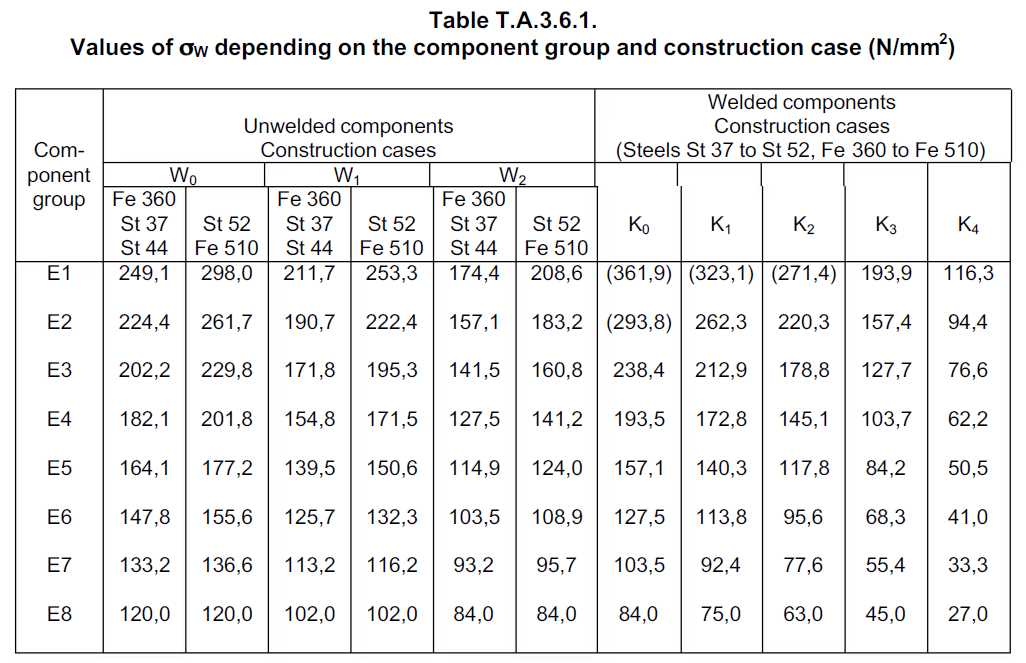

In [39]:
# --------------------------------------------------------------------------------------------------
# TABLA sigma_W - FEM T.A.3.6.1
# --------------------------------------------------------------------------------------------------

TABLA_SIGMA_W = {

    'W0': {
        'St37-St44': [249.1,224.4,202.2,182.1,164.1,147.8,133.2,120.0],
        'St52':      [298.0,261.7,229.8,201.8,177.2,155.6,136.6,120.0]
    },

    'W1': {
        'St37-St44': [211.7,190.7,171.8,154.8,139.5,125.7,113.2,102.0],
        'St52':      [253.3,222.4,195.3,171.5,150.6,132.3,116.2,102.0]
    },

    'W2': {
        'St37-St44': [174.4,157.1,141.5,127.5,114.9,103.5,93.2,84.0],
        'St52':      [208.6,183.2,160.8,141.2,124.0,108.9,95.7,84.0]
    },

    'K0': [361.9,293.8,238.4,193.5,157.1,127.5,103.5,84.0],
    'K1': [323.1,262.3,212.9,172.8,140.3,113.8,92.4,75.0],
    'K2': [271.4,220.3,178.8,145.1,117.8,95.6,77.6,63.0],
    'K3': [193.9,157.4,127.7,103.7,84.2,68.3,55.4,45.0],
    'K4': [116.3,94.4,76.6,62.2,50.5,41.0,33.3,27.0]
}

In [40]:
def sigma_W(E, detalle, acero=None):

    i = int(E[1:]) - 1
    detalle = detalle.upper()

    if detalle in ['W0','W1','W2']: # ELEMENTOS NO SOLDADOS

        if acero not in ['St37-St44','St52']:
            raise ValueError(
                "Para W0/W1/W2 indicar acero='St37-St44' o acero='St52'"
            )

        return TABLA_SIGMA_W[detalle][acero][i]

    elif detalle in ['K0','K1','K2','K3','K4']: # ELEMENTOS SOLDADOS

        return TABLA_SIGMA_W[detalle][i]

    else:
        raise ValueError("Detalle debe ser W0-W2 o K0-K4")

In [41]:
sw = sigma_W(
    E='E6',
    detalle='K4'
)

print(sw)

41.0


In [42]:
# --------------------------------------------------------------------------------------------------
# EXTREMOS DE FATIGA
# --------------------------------------------------------------------------------------------------

def extremos_fatiga(historia):

    vmin = min(historia)
    vmax = max(historia)

    # sigma_max FEM = extremo de mayor valor absoluto
    if abs(vmin) >= abs(vmax):
        sigma_max = vmin
        sigma_min = vmax
    else:
        sigma_max = vmax
        sigma_min = vmin

    if sigma_max == 0:
        kappa = 0.0
    else:
        kappa = sigma_min/sigma_max

    return {
        'sigma_max': sigma_max,
        'sigma_min': sigma_min,
        'kappa': kappa
    }

In [43]:
historia = [-28, -60, -100, -140, -80]
extremos_fatiga(historia)

{'sigma_max': -140, 'sigma_min': -28, 'kappa': 0.2}

In [44]:
# --------------------------------------------------------------------------------------------------
# CAPACIDAD NORMAL A FATIGA
# --------------------------------------------------------------------------------------------------

def sigma_adm_fatiga_normal(E, detalle, kappa, fu, sentido, acero=None):

    sw = sigma_W(E, detalle, acero)

    sentido = sentido.lower()

    if sentido not in ['traccion','compresion']:
        raise ValueError("sentido debe ser 'traccion' o 'compresion'")

    # ------------------------------------------------------------------
    # kappa <= 0
    # ------------------------------------------------------------------
    if kappa <= 0:

        sigma_t = 5*sw/(3 - 2*kappa)
        sigma_t = min(sigma_t, 0.75*fu)

        sigma_c = 2*sw/(1 - kappa)

    # ------------------------------------------------------------------
    # kappa > 0
    # ------------------------------------------------------------------
    else:

        sigma_0 = (5/3)*sw
        sigma_p1 = 0.75*fu

        sigma_t = sigma_0 / (1 - kappa*(1 - sigma_0/sigma_p1))

        sigma_t = min(sigma_t, sigma_p1)

        sigma_c = 1.2*sigma_t

    if sentido == 'traccion':
        sigma_adm = sigma_t
    else:
        sigma_adm = sigma_c

    return {
        'sigma_W': sw,
        'kappa': kappa,
        'sentido': sentido,
        'sigma_t': sigma_t,
        'sigma_c': sigma_c,
        'sigma_adm': sigma_adm
    }

In [45]:
# --------------------------------------------------------------------------------------------------
# CAPACIDAD A CORTE POR FATIGA
# --------------------------------------------------------------------------------------------------

def tau_adm_fatiga(E, kappa, fu, tipo='material', acero=None):

    tipo = tipo.lower()

    if tipo == 'material':

        cap = sigma_adm_fatiga_normal(
            E=E,
            detalle='W0',
            kappa=kappa,
            fu=fu,
            sentido='traccion',
            acero=acero
        )

        tau_a = cap['sigma_t']/sqrt(3)

    elif tipo == 'soldadura':

        cap = sigma_adm_fatiga_normal(
            E=E,
            detalle='K0',
            kappa=kappa,
            fu=fu,
            sentido='traccion'
        )

        tau_a = cap['sigma_t']/sqrt(2)

    else:
        raise ValueError("tipo debe ser 'material' o 'soldadura'")

    return tau_a

In [51]:
tau_adm = tau_adm_fatiga(
    E='E4',
    kappa=-1,
    fu=360,
    tipo='material',
    acero='St37-St44'
)

print(tau_adm)

105.13548401943085


In [52]:
# --------------------------------------------------------------------------------------------------
# INTERACCIÓN DE FATIGA
# --------------------------------------------------------------------------------------------------

def interaccion_fatiga(sx, sy, txy, sxa, sya, txya):

    R = ((sx/sxa)**2 + (sy/sya)**2 - (sx*sy)/(abs(sxa)*abs(sya)) + (txy/txya)**2)

    FU = sqrt(max(R,0))

    return {
        'R': R,
        'FU': FU,
        'OK': R <= 1.0,
        'OK_105': FU <= 1.05
    }

In [ ]:
# --------------------------------------------------------------------------------------------------
# CHECK COMPLETO DE FATIGA DE UN SHELL
# --------------------------------------------------------------------------------------------------

def check_fatiga_shell(
    S11_hist,
    S22_hist,
    S12_hist,
    E,
    detalle_11,
    detalle_22,
    fu,
    acero=None,
    tipo_corte='material'
):

    ex = extremos_fatiga(S11_hist)
    ey = extremos_fatiga(S22_hist)
    et = extremos_fatiga(S12_hist)

    sentido_x = 'traccion' if ex['sigma_max'] >= 0 else 'compresion'
    sentido_y = 'traccion' if ey['sigma_max'] >= 0 else 'compresion'

    cap_x = sigma_adm_fatiga_normal(
        E, detalle_11, ex['kappa'], fu, sentido_x, acero
    )

    cap_y = sigma_adm_fatiga_normal(
        E, detalle_22, ey['kappa'], fu, sentido_y, acero
    )

    tau_a = tau_adm_fatiga(
        E, et['kappa'], fu, tipo_corte, acero
    )

    sxa = cap_x['sigma_adm']
    sya = cap_y['sigma_adm']

    # Para mantener los signos compatibles con sigma_max
    sxa_signed = sxa if ex['sigma_max'] >= 0 else -sxa
    sya_signed = sya if ey['sigma_max'] >= 0 else -sya

    inter = interaccion_fatiga(
        ex['sigma_max'],
        ey['sigma_max'],
        et['sigma_max'],
        sxa_signed,
        sya_signed,
        tau_a
    )

    return {
        'S11': ex,
        'S22': ey,
        'S12': et,

        'sigma_W_11': cap_x['sigma_W'],
        'sigma_W_22': cap_y['sigma_W'],

        'sigma_adm_11': sxa,
        'sigma_adm_22': sya,
        'tau_adm_12': tau_a,

        'FU_11': abs(ex['sigma_max'])/sxa,
        'FU_22': abs(ey['sigma_max'])/sya,
        'FU_12': abs(et['sigma_max'])/tau_a,

        'R_comb': inter['R'],
        'FU_comb': inter['FU'],

        'OK': (
            abs(ex['sigma_max']) <= sxa
            and abs(ey['sigma_max']) <= sya
            and abs(et['sigma_max']) <= tau_a
            and inter['R'] <= 1.0
        )
    }

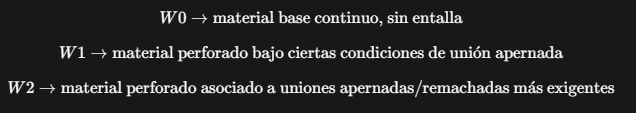

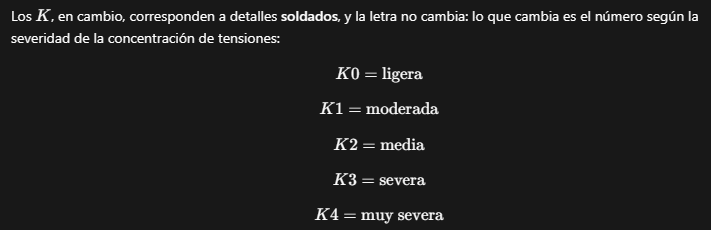

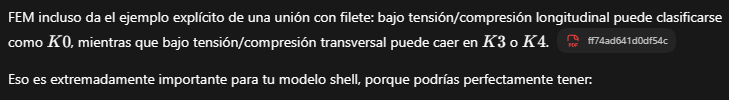

In [58]:
resultado = check_fatiga_shell(
    S11_hist = [-28, -60, -100, -140],
    S22_hist = [0, -30, -70, -100],
    S12_hist = [-40, -20, 0, 20, 40],

    E = 'E4',

    detalle_11 = 'K0',
    detalle_22 = 'K4',

    fu = 360,

    acero = 'St37-St44',
    tipo_corte = 'material'
)

resultado

{'S11': {'sigma_max': -140, 'sigma_min': -28, 'kappa': 0.2},
 'S22': {'sigma_max': -100, 'sigma_min': 0, 'kappa': -0.0},
 'S12': {'sigma_max': -40, 'sigma_min': 40, 'kappa': -1.0},
 'sigma_W_11': 193.5,
 'sigma_W_22': 62.2,
 'sigma_adm_11': 324.0,
 'sigma_adm_22': 124.4,
 'tau_adm_12': 105.13548401943085,
 'FU_11': 0.43209876543209874,
 'FU_22': 0.8038585209003215,
 'FU_12': 0.3804614623984354,
 'R_comb': 0.6303025146192507,
 'FU_comb': 0.7939159367459824,
 'OK': True}

In [59]:
resultado = check_fatiga_shell(

    S11_hist = [-30,-80,-140,-70,-28],
    S22_hist = [0,-40,-100,-50,0],
    S12_hist = [-40,-20,0,20,40],

    E = 'E4',

    detalle_11 = 'K0',
    detalle_22 = 'K4',

    fu = 360,

    tipo_corte = 'soldadura'
)

resultado

{'S11': {'sigma_max': -140, 'sigma_min': -28, 'kappa': 0.2},
 'S22': {'sigma_max': -100, 'sigma_min': 0, 'kappa': -0.0},
 'S12': {'sigma_max': -40, 'sigma_min': 40, 'kappa': -1.0},
 'sigma_W_11': 193.5,
 'sigma_W_22': 62.2,
 'sigma_adm_11': 324.0,
 'sigma_adm_22': 124.4,
 'tau_adm_12': 136.82516215959694,
 'FU_11': 0.43209876543209874,
 'FU_22': 0.8038585209003215,
 'FU_12': 0.29234388886265533,
 'R_comb': 0.5710165396042352,
 'FU_comb': 0.7556563634379289,
 'OK': True}